### 06 - Application des modeles de classification
#### HumanForYou - Attrition ML

**Objectif** : reprendre la partie "application des modeles" du workshop, mais avec les donnees du projet preparees dans le notebook 05.

**Modeles entraines** (7 algorithmes couvrant les familles principales) :
- **Lineaires** : Logistic Regression, Perceptron
- **Basés sur la distance** : SVM, KNN
- **Probabiliste** : Naive Bayes
- **A base d'arbres** : Decision Tree, Random Forest

**Metriques utilisees** : Accuracy, Precision, Recall, F1-score, AUC-ROC
- Le **F1-score** est privilegie car il equilibre precision et rappel, crucial avec un dataset desequilibre (84/16).
- L'**AUC-ROC** mesure la capacite discriminante globale, independamment du seuil de decision.

#### 1. Imports

Cette section charge:
- les modeles de classification,
- les metriques du workshop (confusion matrix, report, precision/recall/f1, AUC, ROC),
- les outils d'export et de visualisation.


In [7]:
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Image, display

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


#### 2. Chargement des donnees preparees (sortie 05)


In [8]:
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
train_path = os.path.join(PROCESSED_DIR, 'attrition_train_prepared.csv')
test_path = os.path.join(PROCESSED_DIR, 'attrition_test_prepared.csv')

assert os.path.exists(train_path), f'Fichier introuvable: {train_path}'
assert os.path.exists(test_path), f'Fichier introuvable: {test_path}'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X_train = train_df.drop(columns=['Attrition']).copy()
y_train = train_df['Attrition'].astype(int).copy()
X_test = test_df.drop(columns=['Attrition']).copy()
y_test = test_df['Attrition'].astype(int).copy()

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print('Distribution y_train:')
print(y_train.value_counts(normalize=True).sort_index())


X_train: (3087, 46) | X_test: (1323, 46)
Distribution y_train:
Attrition
0    0.838678
1    0.161322
Name: proportion, dtype: float64


#### 3. Entrainement, prediction et metriques par modele

Workflow reproduit du workshop:
- `fit` sur train,
- `predict` sur test,
- calcul des metriques et rapports.


In [9]:
def get_positive_proba(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        raw = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-raw))
    return model.predict(X).astype(float)


models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42),
    'Perceptron': Perceptron(random_state=42),
    'SVC': SVC( C=0.5, kernel='rbf', gamma='scale', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=3),
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_split=10, min_samples_leaf=5, max_samples=0.8, class_weight='balanced', random_state=42, n_jobs=-1),
}

predictions_df = pd.DataFrame({'y_true': y_test})
metrics_rows = []
confusion_rows = []
fitted_models = {}
confusion_mats = {}
y_proba_by_model = {}
reports = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = get_positive_proba(model, X_test)

    fitted_models[model_name] = model
    y_proba_by_model[model_name] = y_proba
    predictions_df[f'y_pred_{model_name}'] = y_pred
    predictions_df[f'y_proba_{model_name}'] = y_proba

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    confusion_mats[model_name] = cm
    reports[model_name] = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0,
    )

    confusion_rows.append({
        'model': model_name,
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    })
    metrics_rows.append({
        'model': model_name,
        'accuracy_test': float(accuracy_score(y_test, y_pred)),
        'precision_test': float(precision_score(y_test, y_pred, zero_division=0)),
        'recall_test': float(recall_score(y_test, y_pred, zero_division=0)),
        'f1_test': float(f1_score(y_test, y_pred, zero_division=0)),
        'roc_auc_test': float(roc_auc_score(y_test, y_proba)),
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values('f1_test', ascending=False).reset_index(drop=True)
confusion_df = pd.DataFrame(confusion_rows)

metrics_df


,model,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
0,RandomForest,0.916100,0.752475,0.713615,0.732530,0.951601
1,SVC,0.880574,0.910448,0.286385,0.435714,0.914880
2,NaiveBayes,0.825397,0.451613,0.394366,0.421053,0.762594
3,Perceptron,0.812547,0.410256,0.375587,0.392157,0.734581
4,LogisticRegression,0.855631,0.622222,0.262911,0.369637,0.809237
5,KNN,0.831444,0.460938,0.276995,0.346041,0.874861
6,DecisionTree,0.851096,0.722222,0.122066,0.208835,0.728973


#### 4. Visualisations workshop (confusion matrices + ROC)


Saved: ..\reports\figures\attrition_workshop_confusion_matrices.png
Saved: ..\reports\figures\attrition_workshop_roc_curves.png


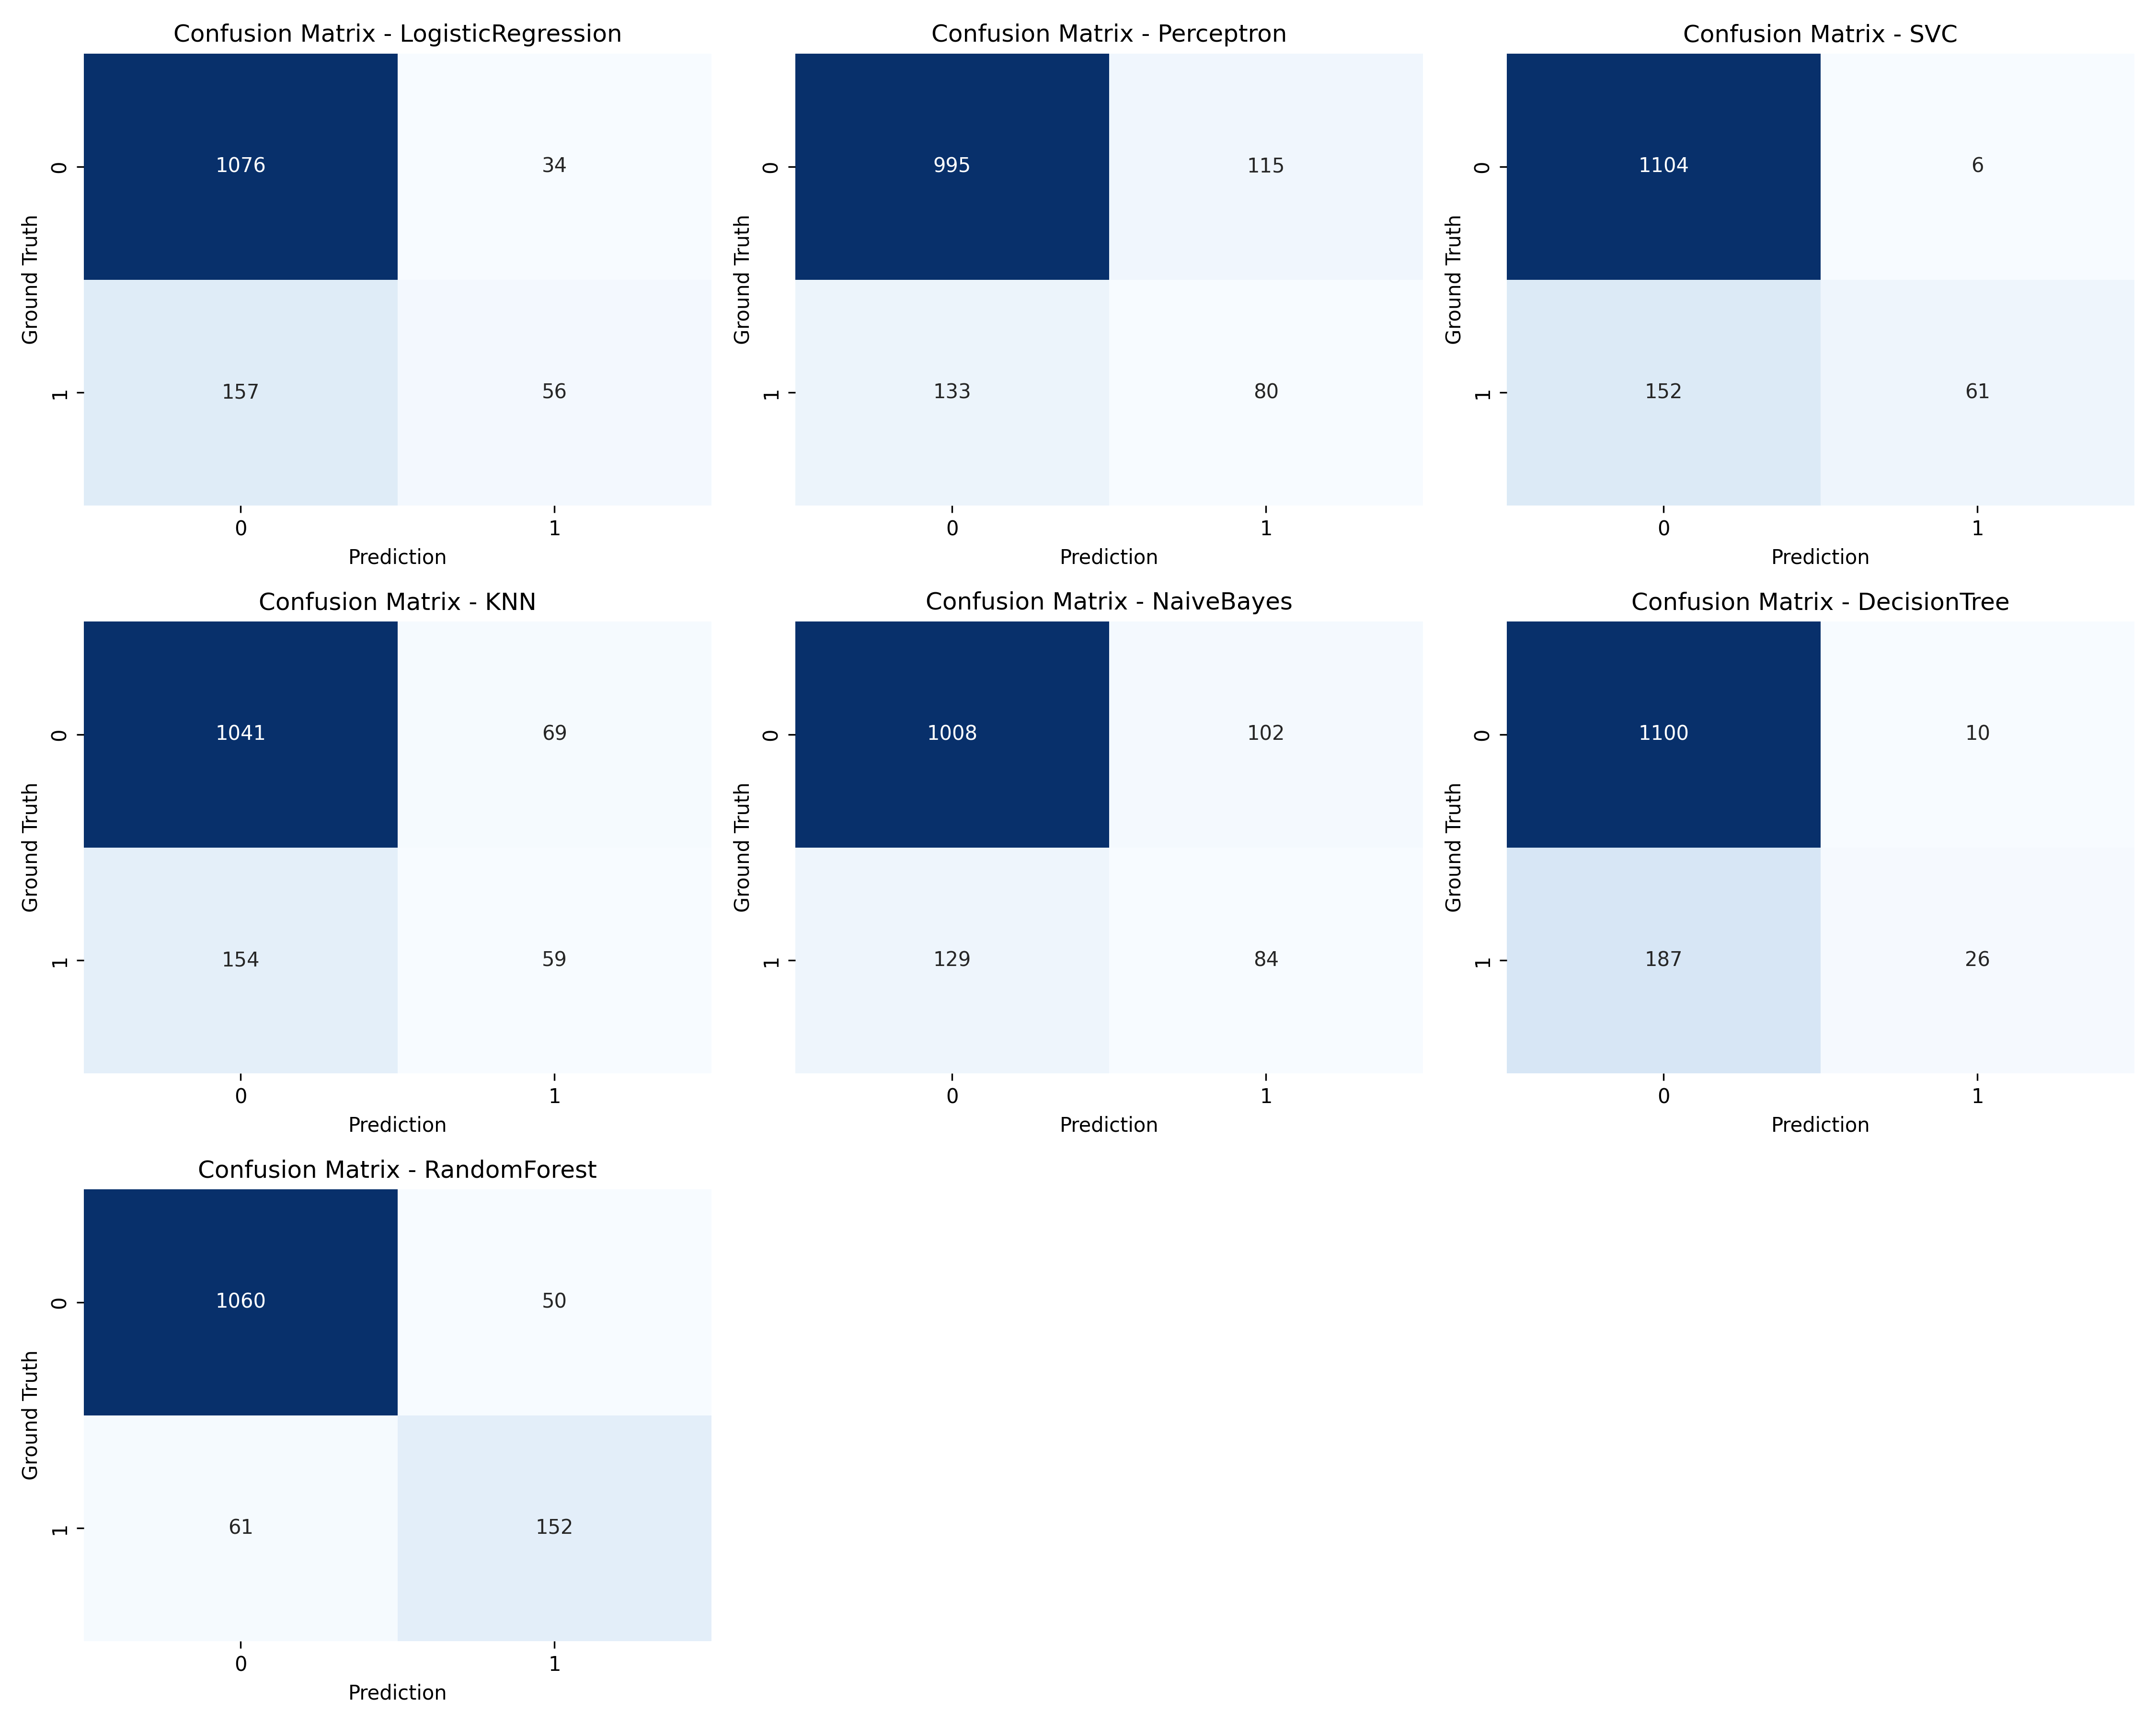

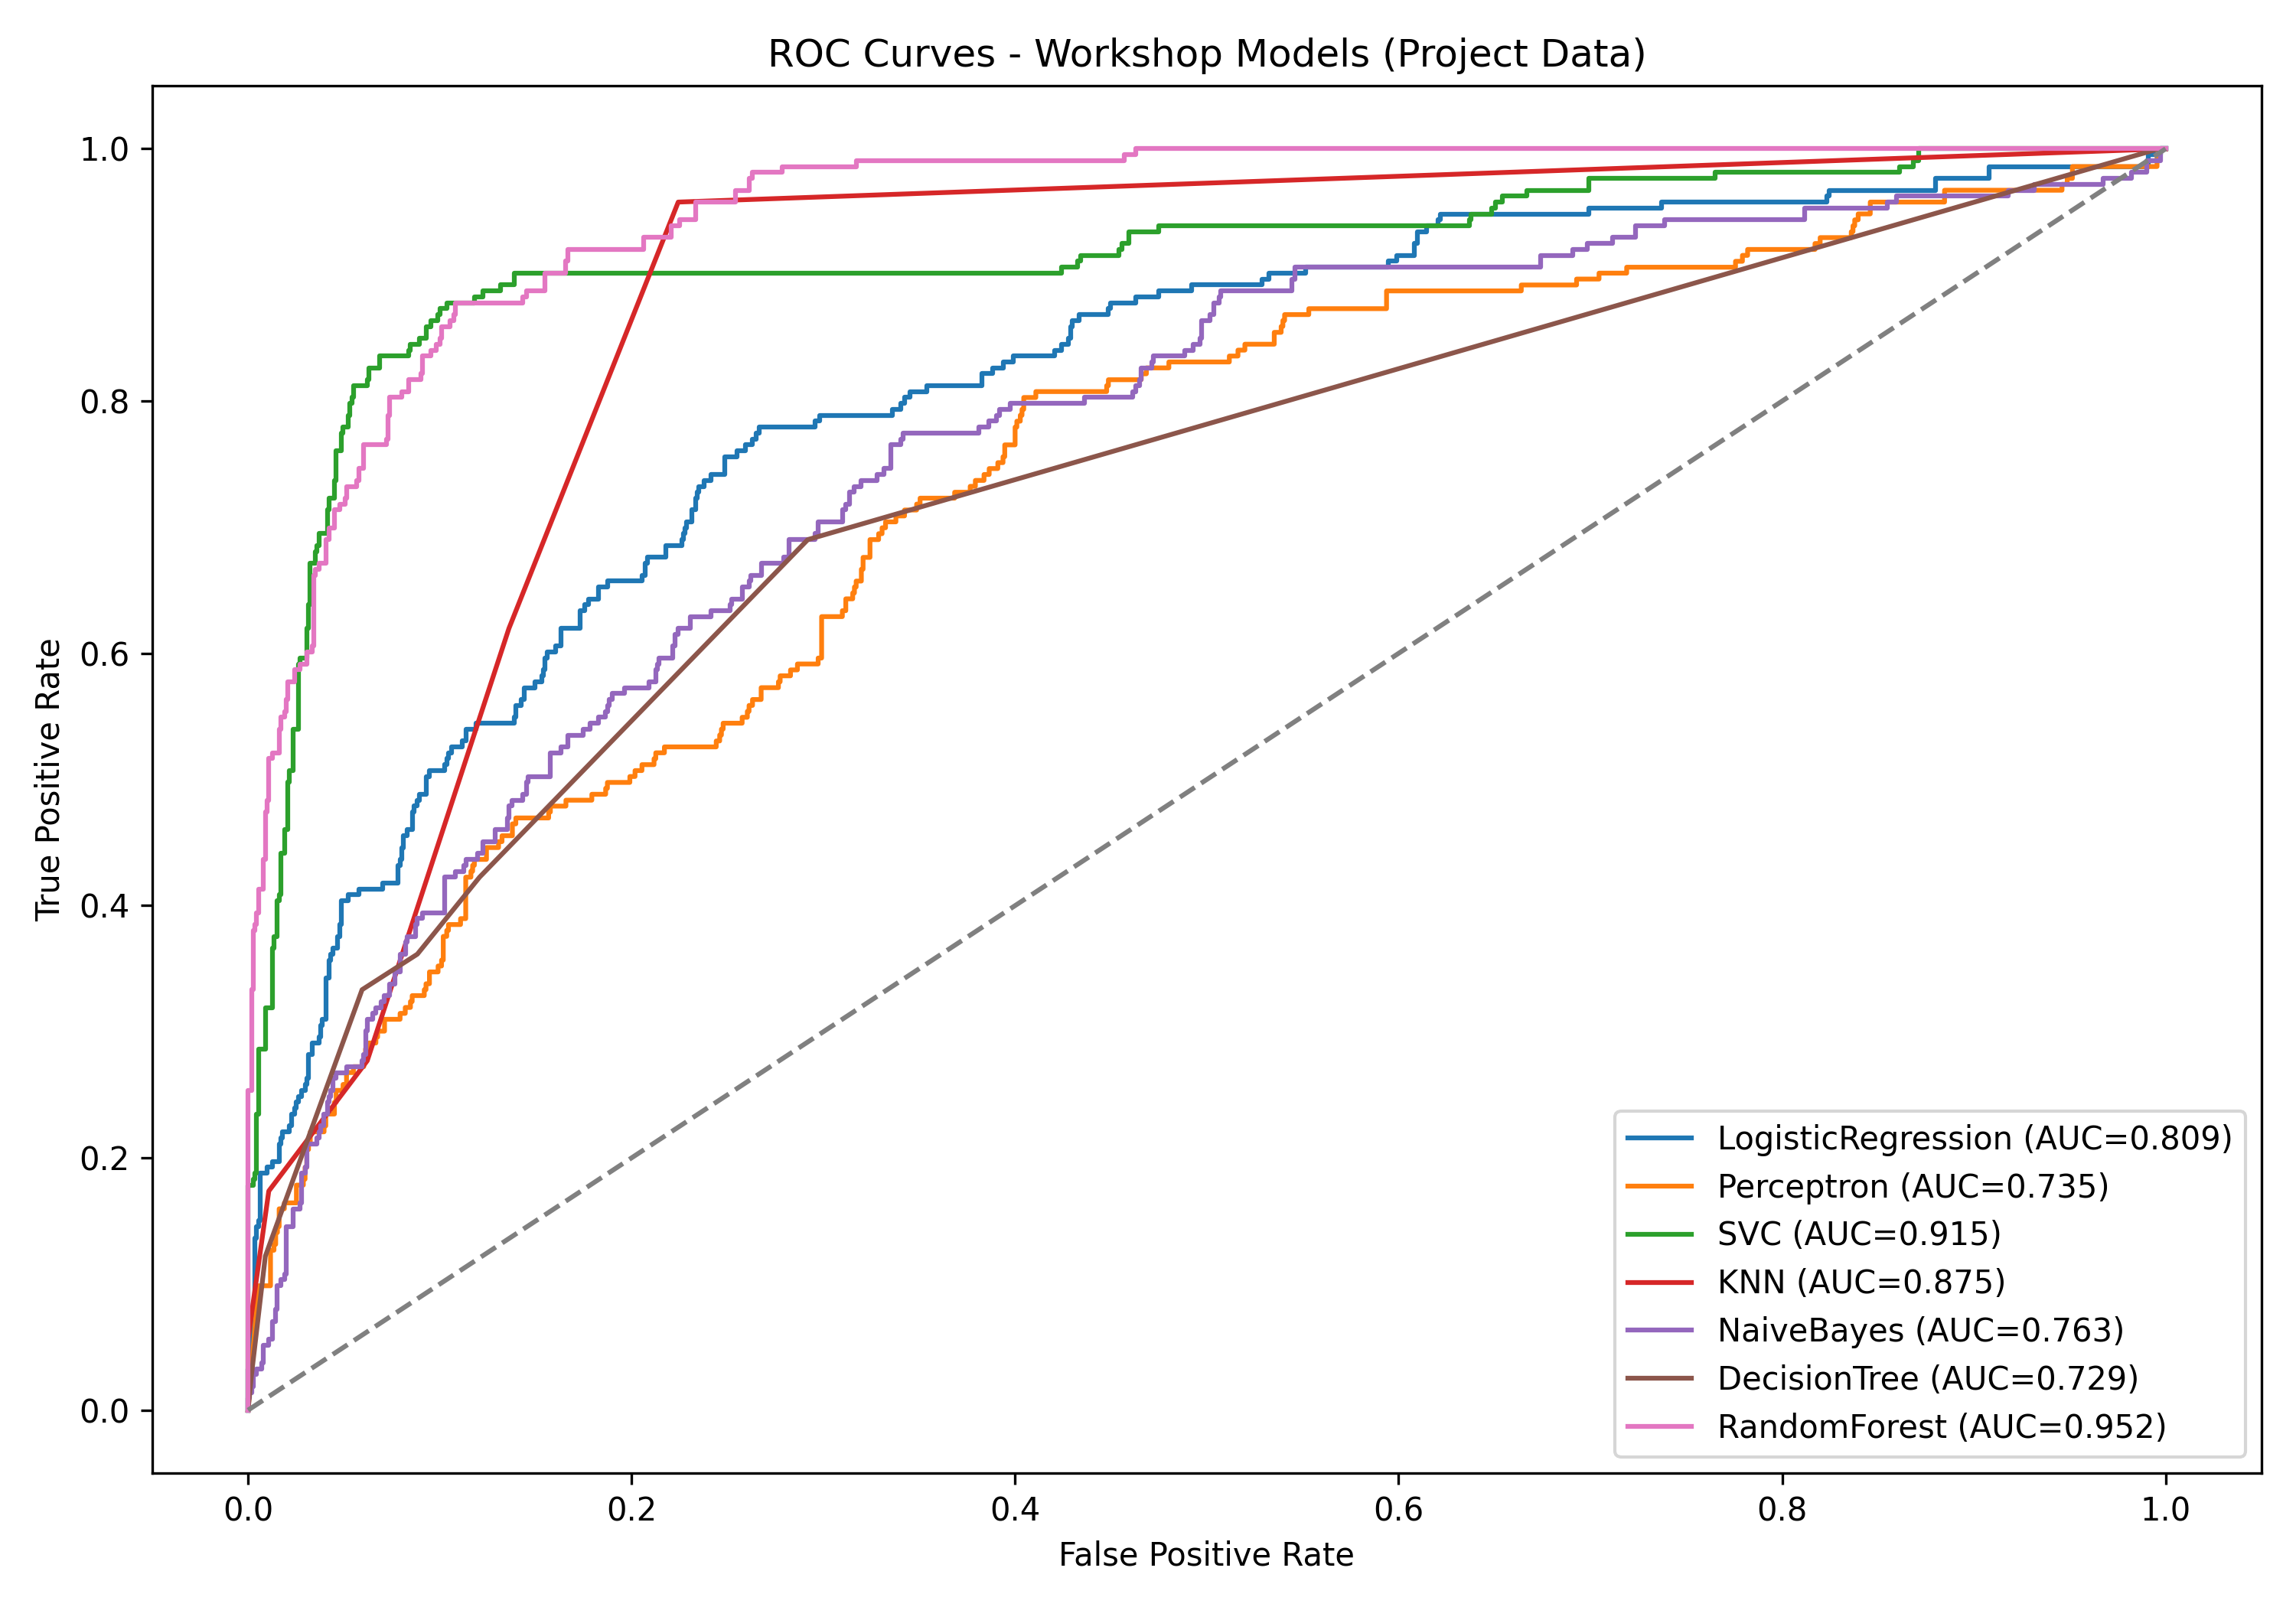

In [10]:
FIG_DIR = os.path.join('..', 'reports', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

model_names = list(models.keys())
n_models = len(model_names)
n_cols = 3
n_rows = math.ceil(n_models / n_cols)

# Matrices de confusion
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for idx, model_name in enumerate(model_names):
    ax = axes[idx]
    cm = confusion_mats[model_name]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_xlabel('Prediction')
    ax.set_ylabel('Ground Truth')

for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
confusion_fig_path = os.path.join(FIG_DIR, 'attrition_workshop_confusion_matrices.png')
plt.savefig(confusion_fig_path, dpi=300)
plt.close()

# Courbes ROC multi-modeles
plt.figure(figsize=(10, 7))
for model_name in model_names:
    y_proba = y_proba_by_model[model_name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Workshop Models (Project Data)')
plt.legend(loc='lower right')
plt.tight_layout()
roc_multi_fig_path = os.path.join(FIG_DIR, 'attrition_workshop_roc_curves.png')
plt.savefig(roc_multi_fig_path, dpi=300)
plt.close()

print(f'Saved: {confusion_fig_path}')
print(f'Saved: {roc_multi_fig_path}')

display(Image(filename=confusion_fig_path))
display(Image(filename=roc_multi_fig_path))


#### 5. Exports CSV/JSON

Exports workshop complets + conservation des sorties historiques du notebook 06
(`attrition_linear_*`) pour garder la continuite du projet.


Saved: ..\data\processed\attrition_workshop_models_metrics.csv
Saved: ..\data\processed\attrition_workshop_models_predictions_test.csv
Saved: ..\data\processed\attrition_workshop_models_confusion_matrices.csv
Saved: ..\data\processed\attrition_workshop_classification_reports.json
Saved: ..\data\processed\attrition_linear_metrics.csv
Saved: ..\data\processed\attrition_linear_test_predictions.csv
Saved: ..\data\processed\attrition_linear_coefficients.csv
Saved: ..\reports\figures\attrition_linear_top_coefficients.png
Saved: ..\reports\figures\attrition_linear_roc_curve.png


,model,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
0,LogisticRegression,0.855631,0.622222,0.262911,0.369637,0.809237


,feature,coefficient
12,YearsWithCurrManager,-0.674008
18,avg_work_hours,0.620706
8,TotalWorkingYears,-0.541098
11,YearsSinceLastPromotion,0.440921
19,cluster,-0.424636
0,Age,-0.414339
13,EnvironmentSatisfaction,-0.412747
17,PerformanceRating,-0.408271
14,JobSatisfaction,-0.400650
5,NumCompaniesWorked,0.359954


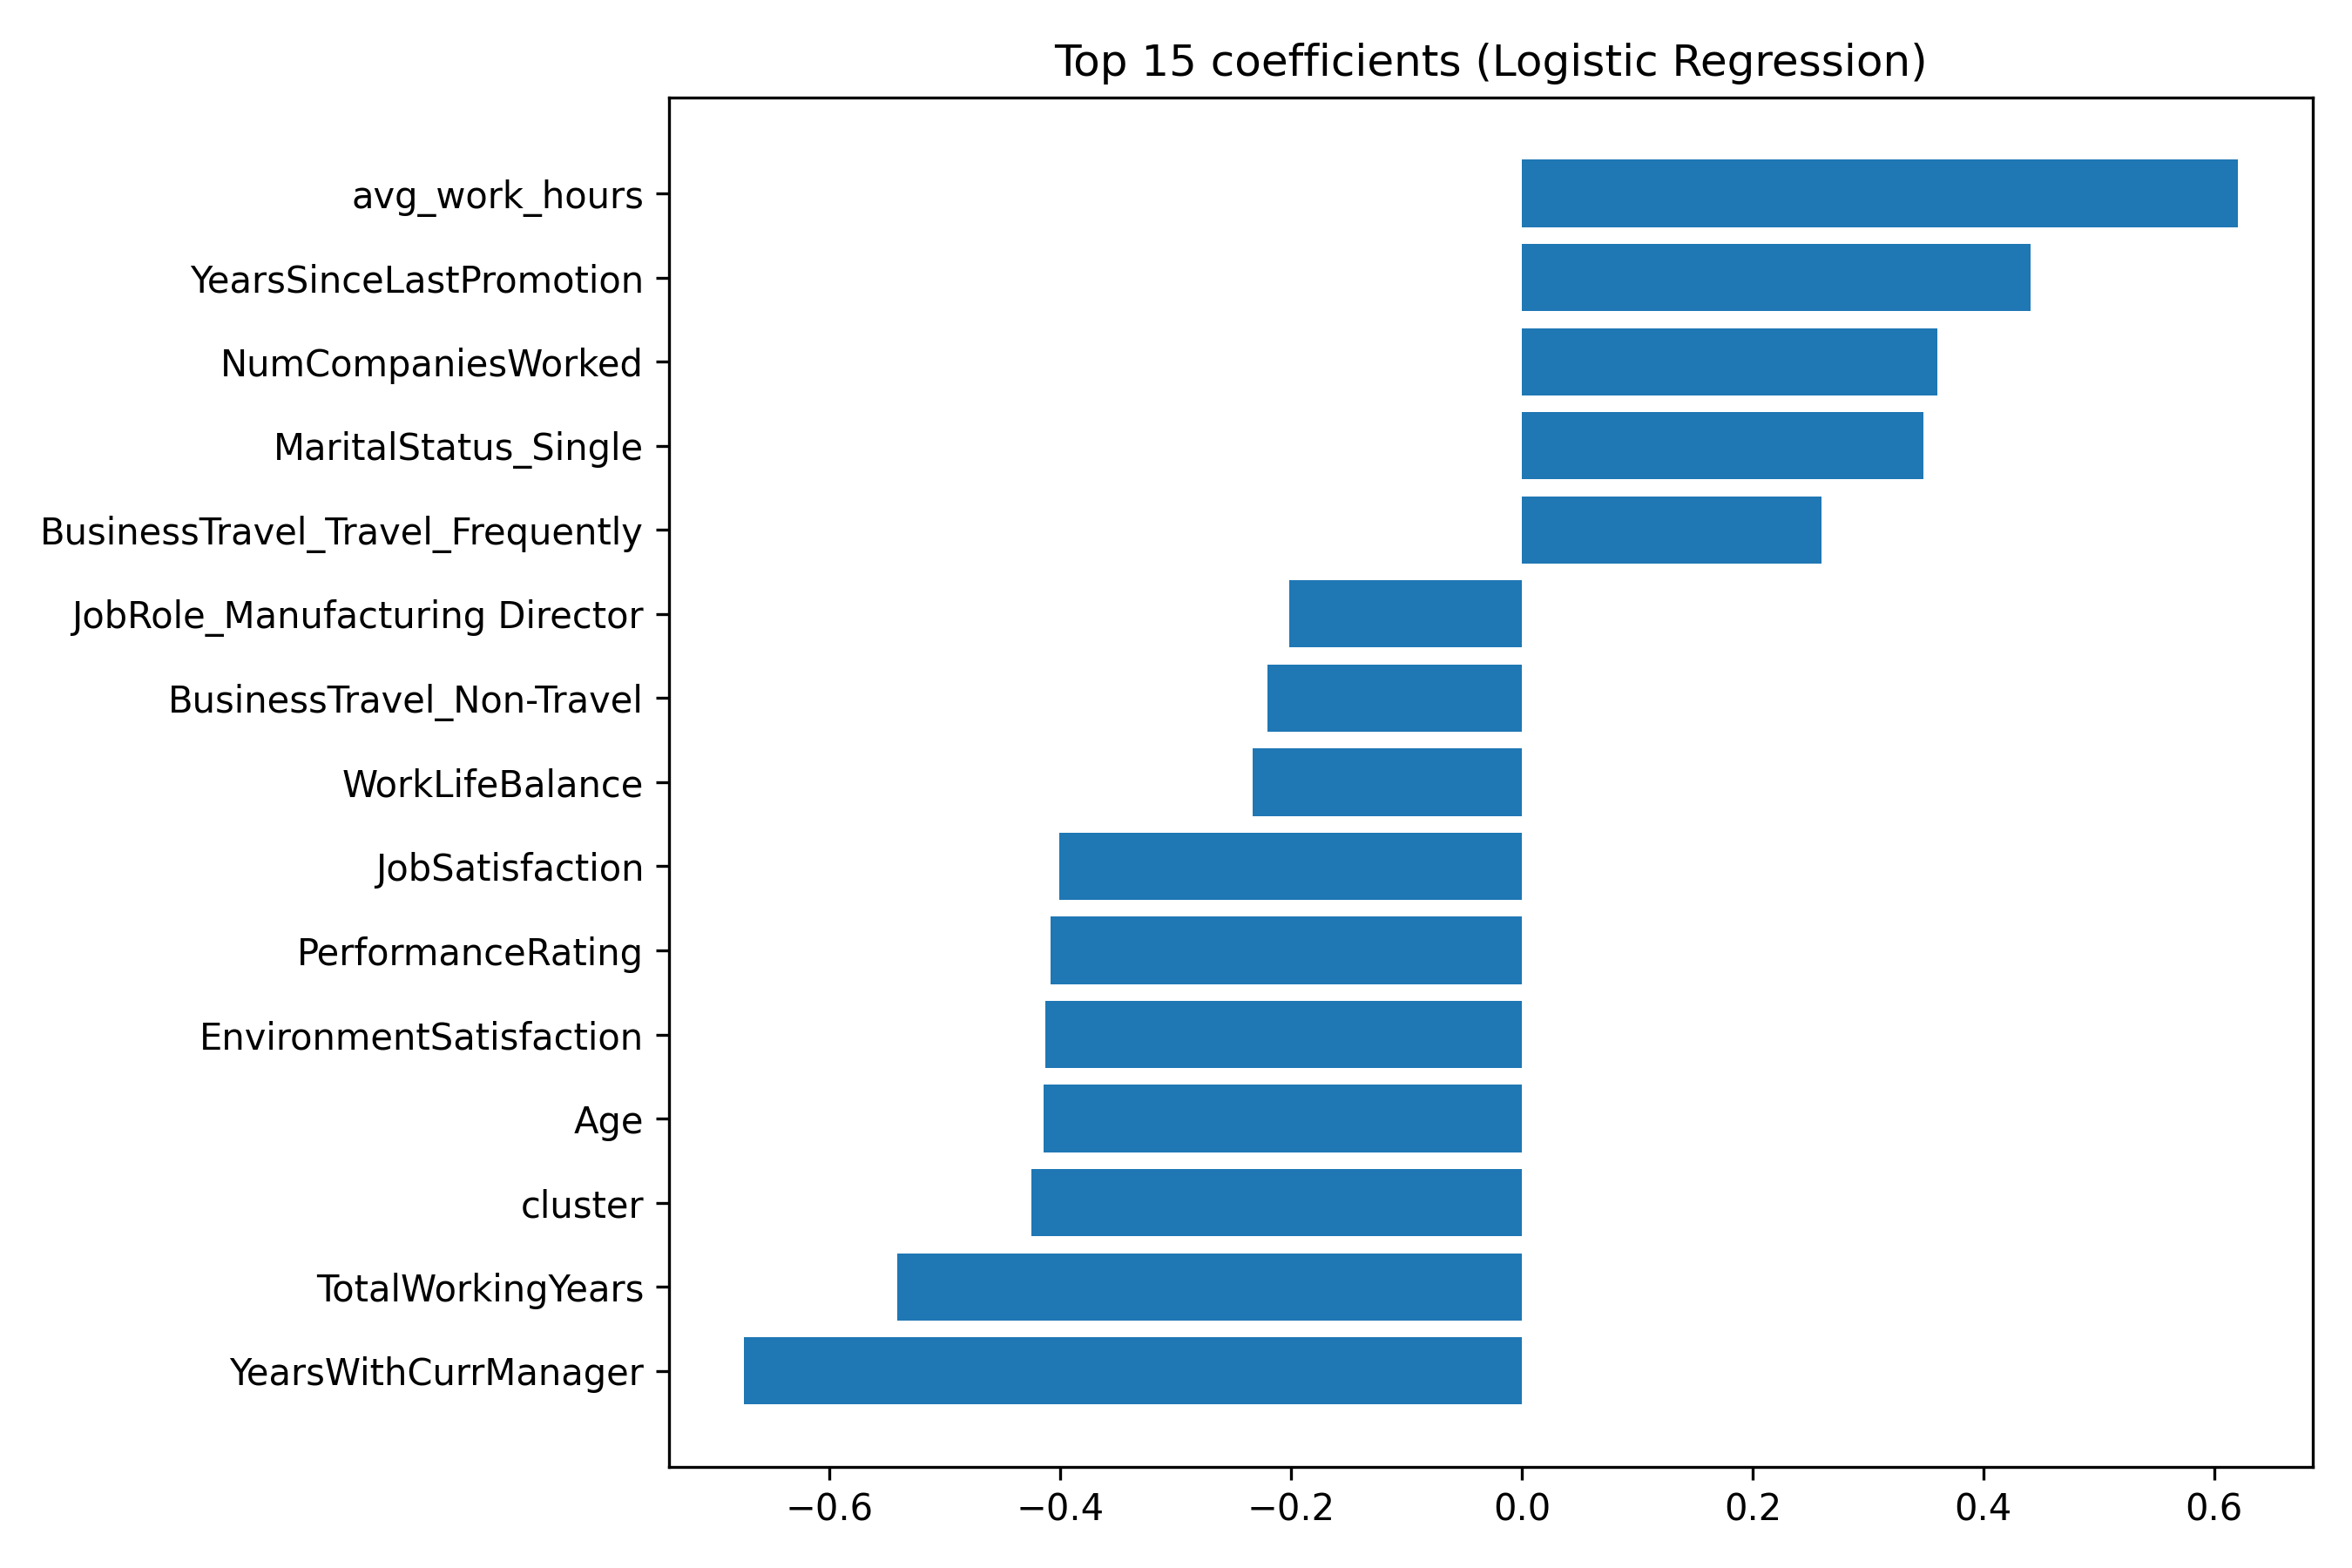

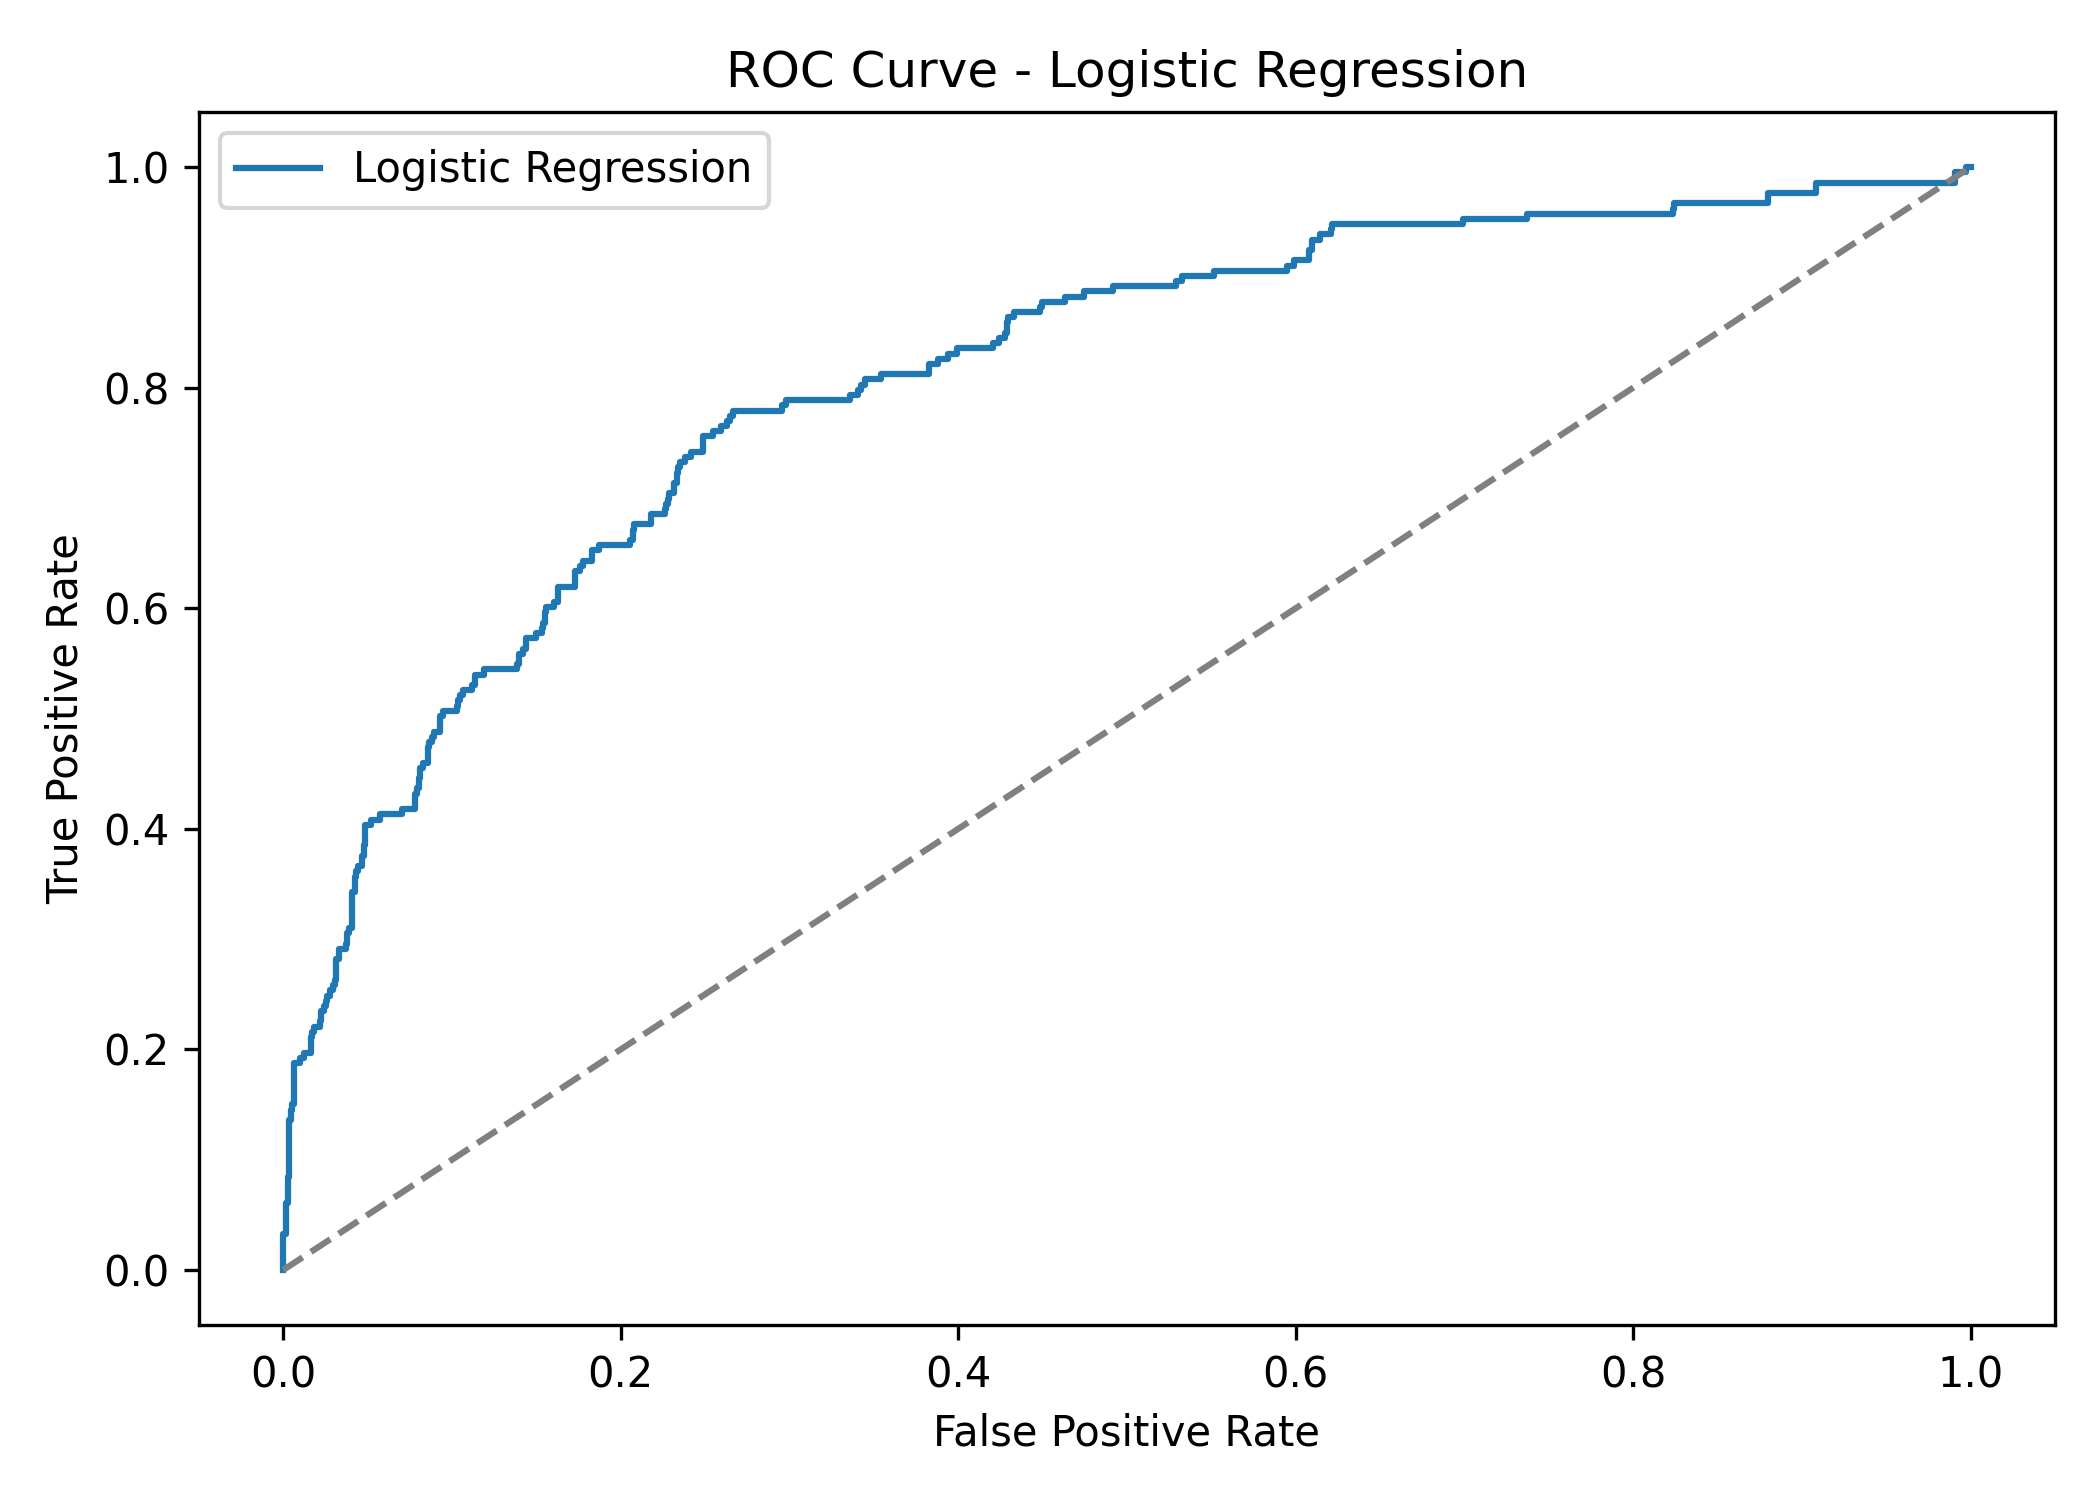

In [11]:
def to_python_types(obj):
    if isinstance(obj, dict):
        return {k: to_python_types(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_python_types(v) for v in obj]
    if hasattr(obj, 'item'):
        return obj.item()
    return obj


# Exports workshop
workshop_metrics_path = os.path.join(PROCESSED_DIR, 'attrition_workshop_models_metrics.csv')
workshop_preds_path = os.path.join(PROCESSED_DIR, 'attrition_workshop_models_predictions_test.csv')
workshop_confusion_path = os.path.join(PROCESSED_DIR, 'attrition_workshop_models_confusion_matrices.csv')
workshop_reports_path = os.path.join(PROCESSED_DIR, 'attrition_workshop_classification_reports.json')

metrics_df.to_csv(workshop_metrics_path, index=False)
predictions_df.to_csv(workshop_preds_path, index=False)
confusion_df.to_csv(workshop_confusion_path, index=False)

with open(workshop_reports_path, 'w', encoding='utf-8') as f:
    json.dump(to_python_types(reports), f, ensure_ascii=False, indent=2)

# Sorties historiques (Logistic Regression)
logistic_model = fitted_models['LogisticRegression']
logistic_proba = y_proba_by_model['LogisticRegression']
logistic_pred = predictions_df['y_pred_LogisticRegression'].to_numpy()

linear_metrics_df = pd.DataFrame([
    {
        'model': 'LogisticRegression',
        'accuracy_test': float(accuracy_score(y_test, logistic_pred)),
        'precision_test': float(precision_score(y_test, logistic_pred, zero_division=0)),
        'recall_test': float(recall_score(y_test, logistic_pred, zero_division=0)),
        'f1_test': float(f1_score(y_test, logistic_pred, zero_division=0)),
        'roc_auc_test': float(roc_auc_score(y_test, logistic_proba)),
    }
])

linear_predictions_df = pd.DataFrame({
    'y_true': y_test,
    'y_proba_logistic': logistic_proba,
    'y_pred_logistic': logistic_pred,
})

linear_coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': logistic_model.coef_.ravel(),
}).sort_values('coefficient', key=np.abs, ascending=False)

metrics_path = os.path.join(PROCESSED_DIR, 'attrition_linear_metrics.csv')
preds_path = os.path.join(PROCESSED_DIR, 'attrition_linear_test_predictions.csv')
coef_path = os.path.join(PROCESSED_DIR, 'attrition_linear_coefficients.csv')

linear_metrics_df.to_csv(metrics_path, index=False)
linear_predictions_df.to_csv(preds_path, index=False)
linear_coef_df.to_csv(coef_path, index=False)

# Figures historiques logistic
top_coef = linear_coef_df.head(15).sort_values('coefficient')
plt.figure(figsize=(9, 6))
plt.barh(top_coef['feature'], top_coef['coefficient'])
plt.title('Top 15 coefficients (Logistic Regression)')
plt.tight_layout()
coef_fig_path = os.path.join(FIG_DIR, 'attrition_linear_top_coefficients.png')
plt.savefig(coef_fig_path, dpi=300)
plt.close()

fpr_lr, tpr_lr, _ = roc_curve(y_test, logistic_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
roc_fig_path = os.path.join(FIG_DIR, 'attrition_linear_roc_curve.png')
plt.savefig(roc_fig_path, dpi=300)
plt.close()

print(f'Saved: {workshop_metrics_path}')
print(f'Saved: {workshop_preds_path}')
print(f'Saved: {workshop_confusion_path}')
print(f'Saved: {workshop_reports_path}')
print(f'Saved: {metrics_path}')
print(f'Saved: {preds_path}')
print(f'Saved: {coef_path}')
print(f'Saved: {coef_fig_path}')
print(f'Saved: {roc_fig_path}')

display(linear_metrics_df)
display(linear_coef_df.head(20))
display(Image(filename=coef_fig_path))
display(Image(filename=roc_fig_path))


---

#### 6. Analyse des erreurs et discussion

##### 6.1 Interpretation des matrices de confusion

Dans un contexte RH de prediction d'attrition, les **Faux Negatifs (FN)** et **Faux Positifs (FP)** n'ont pas le meme cout :

| Type d'erreur | Signification RH | Cout |
|---|---|---|
| **Faux Negatif (FN)** | Employe a risque **non detecte** → depart non anticipe | **Eleve** : perte de talent, cout de remplacement (50-200 % salaire annuel) |
| **Faux Positif (FP)** | Employe stable identifie a tort comme "a risque" → ressources de retention mal ciblees | **Modere** : cout organisationnel, actions inutiles mais pas destructrices |

**Consequence** : le **Recall** (taux de detection des vrais positifs) est plus critique que la Precision dans notre cas. Un modele avec un bon recall detecte davantage d'employes a risque, meme au prix de quelques fausses alertes.

In [12]:
# Analyse detaillee des erreurs pour chaque modele.
print("=== ANALYSE DES ERREURS (FP / FN) PAR MODELE ===\n")
print(f"{'Modele':25s} | {'Accuracy':>8s} | {'Precision':>9s} | {'Recall':>6s} | {'F1':>5s} | {'FP':>4s} | {'FN':>4s} | {'AUC':>5s}")
print("-" * 95)

for _, row in metrics_df.iterrows():
    model_name = row['model']
    y_pred = predictions_df[f'y_pred_{model_name}'].to_numpy()
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"{model_name:25s} | {row['accuracy_test']:8.3f} | {row['precision_test']:9.3f} | {row['recall_test']:6.3f} | {row['f1_test']:5.3f} | {fp:4d} | {fn:4d} | {row['roc_auc_test']:5.3f}")

print(f"\nTotal test positifs (Attrition=1): {y_test.sum()}")
print(f"Total test negatifs (Attrition=0): {(y_test == 0).sum()}")

=== ANALYSE DES ERREURS (FP / FN) PAR MODELE ===

Modele                    | Accuracy | Precision | Recall |    F1 |   FP |   FN |   AUC
-----------------------------------------------------------------------------------------------
RandomForest              |    0.916 |     0.752 |  0.714 | 0.733 |   50 |   61 | 0.952
SVC                       |    0.881 |     0.910 |  0.286 | 0.436 |    6 |  152 | 0.915
NaiveBayes                |    0.825 |     0.452 |  0.394 | 0.421 |  102 |  129 | 0.763
Perceptron                |    0.813 |     0.410 |  0.376 | 0.392 |  115 |  133 | 0.735
LogisticRegression        |    0.856 |     0.622 |  0.263 | 0.370 |   34 |  157 | 0.809
KNN                       |    0.831 |     0.461 |  0.277 | 0.346 |   69 |  154 | 0.875
DecisionTree              |    0.851 |     0.722 |  0.122 | 0.209 |   10 |  187 | 0.729

Total test positifs (Attrition=1): 213
Total test negatifs (Attrition=0): 1110


##### 6.2 Discussion Overfitting

**Risque principal** : un modele qui memorise le train et generalise mal sur le test.

**Indicateurs disponibles** :
- La comparaison des metriques train vs test sera realisee en detail dans le notebook 07 (cross-validation).
- Dans ce notebook, l'utilisation d'un **test set non vu** (30 % des donnees) fournit une premiere estimation honnete de la generalisation.

**Observations** :
- **Decision Tree** (max_depth=3) : la profondeur est volontairement limitee pour eviter le sur-apprentissage. Un arbre non contraint memoriserait le train a 100 %.
- **Random Forest** : l'agregation de 100 arbres reduit naturellement la variance (bagging), ce qui le rend plus robuste a l'overfitting qu'un arbre seul.
- **Logistic Regression** : modele lineaire simple avec peu de risque d'overfitting, surtout avec `max_iter=2000` pour garantir la convergence.
- **KNN** : sensible au nombre de voisins (k=5 par defaut) — un k trop faible sur-apprend, un k trop grand sous-apprend.

La **cross-validation 5-fold** dans le notebook 07 confirmera la stabilite des resultats.

---

#### Mini-conclusion — Notebook 06

**Ce qui a ete fait** :
- Entrainement de 7 modeles de classification sur les donnees preparees
- Calcul des metriques de performance (Accuracy, Precision, Recall, F1, AUC-ROC)
- Visualisation : matrices de confusion multi-modeles, courbes ROC comparatives
- Analyse des erreurs FP/FN et de leur impact RH
- Export des coefficients de la regression logistique (interpretabilite)

**Constats preliminaires** :
- Les modeles a base d'arbres (Random Forest) et la Logistic Regression tendent a offrir le meilleur compromis F1/AUC
- Le recall est critique dans ce contexte RH (minimiser les departs non detectes)
- L'overfitting est controle par les hyperparametres choisis

**Prochaine etape** : Notebook 07 — Comparaison approfondie avec cross-validation et choix du modele final